# TP 2 — Profiling & périmètre — NutriScope

> **Objectif :** connaître le jeu de données à fond et décider sur quoi porte NutriScope.

---

## 1. Profiling systématique des données

**Responsable : Sacha**

> Cette partie profile le périmètre France du dataset `food.parquet` récupéré au TP1 : distributions, cardinalités, doublons de codes-barres, incohérences d'unités, valeurs impossibles. Le code ci-dessous est exécuté directement dans ce notebook (cf. aussi `tp2_profiling_template.ipynb` pour le détail du profiling nutritionnel complémentaire).

### 1.0 Chargement des données

In [1]:
import pandas as pd
import duckdb
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Périmètre France, colonnes utiles au profiling (cf. tp2_profiling_template.ipynb)
important_columns = [
    "code", "brands", "brands_tags",
    "categories_tags", "countries_tags", "quantity",
    "serving_size", "nutriscore_grade", "nutriscore_score",
    "nova_group", "environmental_score_grade", "completeness", "no_nutrition_data"
]
cols = ", ".join(f'"{c}"' for c in important_columns)

food_df = duckdb.sql(f"""
    SELECT {cols}
    FROM '../data/food.parquet'
    WHERE 'en:france' in countries_tags
""").df()

food_df.shape

(1247336, 13)

### 1.1 Distributions

**Nombre total de produits** rattachés à `en:france` :

In [3]:
print(f"Nombre total de produits (France) : {len(food_df)}")

Nombre total de produits (France) : 1247336


**Distributions des principales variables numériques.** `nutriments` est une liste de structures `{name, value, "100g", unit, ...}` : on utilise `UNNEST` dans DuckDB pour ne remonter que les nutriments clés, sous forme de table longue (une ligne par (produit, nutriment)).

In [4]:
nutrients_df = duckdb.sql("""
    SELECT t.code AS code, u.entry.name AS nutrient,
           u.entry."100g" AS value_100g, u.entry.unit AS unit
    FROM '../data/food.parquet' t, UNNEST(t.nutriments) AS u(entry)
    WHERE 'en:france' IN t.countries_tags
      AND u.entry.name IN ('energy', 'energy-kcal', 'sugars', 'salt',
                            'proteins', 'carbohydrates', 'fat',
                            'saturated-fat', 'fiber')
""").df()

nutrients_df.shape

(7410858, 4)

In [5]:
key_nutrients = ["energy", "sugars", "salt", "proteins", "carbohydrates",
                  "fat", "saturated-fat", "fiber"]

desc = (
    nutrients_df[nutrients_df["nutrient"].isin(key_nutrients)]
    .groupby("nutrient")["value_100g"]
    .describe(percentiles=[.5, .95, .99])
)
desc.round(2)

c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1037: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)


,count,mean,std,min,50%,95%,99%,max
nutrient,,,,,,,,
carbohydrates,881125.0,2.701000e+01,28.74,0.00,14.00,77.30,94.0,4.010000e+03
energy,888213.0,1.242702e+04,10610642.00,-700.00,1091.50,2383.50,3404.0,1.000000e+10
fat,880864.0,1.433000e+01,18.47,-0.00,8.10,46.00,92.0,3.257000e+03
fiber,379988.0,3.100000e+00,12.39,-0.42,1.50,11.00,26.3,6.636000e+03
proteins,882511.0,9.070000e+00,45.04,-0.01,6.30,26.00,41.2,4.093900e+04
salt,826467.0,1.280000e+00,9.21,0.00,0.55,4.00,13.0,5.000000e+03
saturated-fat,879680.0,5.420000e+00,8.15,-3.62,2.02,20.30,28.9,1.238000e+03
sugars,880782.0,1.333721e+27,inf,0.00,3.50,58.03,80.3,1.174717e+33


Les `max` sont déjà visiblement aberrants (sucres jusqu'à ~1,17 × 10³³ g/100g) — creusé en détail en 1.5. Distributions du Nutri-Score et de NOVA :

In [6]:
print(food_df["nutriscore_grade"].value_counts(dropna=False).to_string())
print()
print(food_df["nutriscore_score"].describe().round(2).to_string())
print()
print(food_df["nova_group"].value_counts(dropna=False).sort_index().to_string())

nutriscore_grade
unknown           717597
e                 132145
d                 122533
c                  96394
a                  63117
b                  49568
not-applicable     40942
NaN                25040

count    463757.0
mean        11.17
std         10.09
min         -17.0
25%           3.0
50%          11.0
75%          19.0
max          53.0

nova_group
1        43976
2        26432
3        71001
4       192085
<NA>    913842


**Taux de valeurs manquantes** sur les colonnes clés (cardinalités, dont celle de `categories_tags` une fois "explosée" : cf. 1.2) :

In [ ]:
print((food_df.isna().mean() * 100).round(2).to_string())

code                          0.00
brands                       43.53
brands_tags                  43.52
categories_tags              46.98
countries_tags                0.00
quantity                     54.35
serving_size                 88.69
nutriscore_grade              2.01
nutriscore_score             62.82
nova_group                   73.26
environmental_score_grade     2.02
completeness                  0.00
no_nutrition_data            94.53


**Autre distribution pertinente :** `completeness`, documenté comme un score entre 0 et 1. 

Au plus un produit a de champs renseignés dans sa fiche (nom, marque, quantité, nutriments, ingrédients, photo, catégories...), plus son completeness se rapproche de 1.

count    1247324.000
mean           0.449
std            0.244
min            0.000
25%            0.275
50%            0.375
75%            0.587
max            1.100


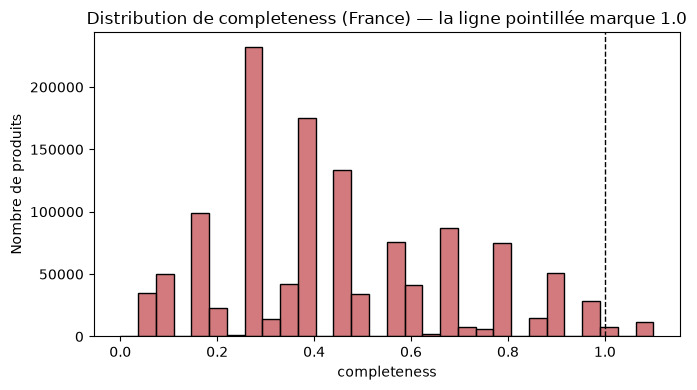

In [8]:
print(food_df["completeness"].describe().round(3).to_string())

plt.figure(figsize=(7, 4))
sns.histplot(food_df["completeness"].dropna(), bins=30, color="#C44E52")
plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution de completeness (France) — la ligne pointillée marque 1.0")
plt.xlabel("completeness")
plt.ylabel("Nombre de produits")
plt.tight_layout()
plt.show()

**Interprétation :** `energy`/`energy-kcal`/`proteins`/`carbohydrates`/`fat`/`saturated-fat`/`sugars` sont renseignés pour ~70-71 % des produits, `salt` pour 66 %, `fiber` seulement 30 %. `nutriscore_grade` compte 7 différentes valeurs dont 2 représentant des valeurs non applicables (`unknown`, `not-applicable`) à traiter comme manquant fonctionnellement en plus des 2,01 % de vrais NaN ; `nutriscore_score` est manquant pour 62,82 % des produits ; `nova_group` pour 73,26 %. `categories_tags` est manquante pour 46,98 % des produits — sa cardinalité une fois explosée est examinée en 1.2. Enfin, `completeness` dépasse sa borne documentée de 1,0 sur la queue de distribution (creusé en 1.5).

---

### 1.2 Cardinalités

In [ ]:
def nunique_list_col(series):
    valeurs = set()
    for v in series.dropna():
        for tag in v:
            valeurs.add(tag)
    return len(valeurs)

scalar_cols = ["code", "brands", "nutriscore_grade", "nova_group",
               "environmental_score_grade", "quantity", "serving_size"]
cardinalites = pd.DataFrame({
    "colonne": scalar_cols,
    "nunique": [food_df[c].nunique(dropna=True) for c in scalar_cols],
    "n_manquants": [food_df[c].isna().sum() for c in scalar_cols],
})
print(cardinalites.to_string(index=False))
print()
print(f"Cardinalité brands_tags (tags explosés)     : {nunique_list_col(food_df['brands_tags'])}")
print(f"Cardinalité categories_tags (tags explosés) : {nunique_list_col(food_df['categories_tags'])}")

                  colonne  nunique  n_manquants
                     code  1247309            0
                   brands   113784       542919
         nutriscore_grade        7        25040
               nova_group        4       913842
environmental_score_grade        9        25159
                 quantity    28870       677926
             serving_size    18010      1106298

Cardinalité brands_tags (tags explosés)     : 86322
Cardinalité categories_tags (tags explosés) : 37442


**Lecture :** `code` est quasi une clé unique (1 247 309 valeurs pour 1 247 336 lignes). `brands` (texte libre, 113 784 valeurs) descend à 86 322 une fois normalisée en `brands_tags`, mais reste élevée : la casse/les espaces ne sont pas toujours harmonisés (ex. « Taste of Nature » / « Taste Of Nature » vues en 1.3) — préférer `brands_tags` à `brands` pour tout regroupement par marque. `quantity` (28 870 valeurs) et `serving_size` (18 010) sont du texte libre à cardinalité trop élevée pour du filtrage direct (cf. 1.4). `categories_tags` compte 37 442 tags distincts une fois explosée (pour 46,98 % de valeurs manquantes, cf. 1.1) — bien trop pour servir de facette brute, un mapping vers les 6 rayons retenus (§3.1) sera nécessaire.

In [10]:
duplicate_stats = pd.DataFrame({
    "nb_codes_uniques": [food_df["code"].nunique()],
    "nb_codes_dupliques": [(food_df["code"].value_counts() > 1).sum()],
    "nb_lignes_concernees": [food_df.duplicated(subset=["code"], keep=False).sum()],
})
print(duplicate_stats.to_string(index=False))

group_sizes = food_df["code"].value_counts()
group_sizes = group_sizes[group_sizes > 1]
print()
print("Répartition de la taille des groupes de codes dupliqués :")
print(group_sizes.value_counts().rename_axis("taille_du_groupe").rename("nb_codes").to_string())

 nb_codes_uniques  nb_codes_dupliques  nb_lignes_concernees
          1247309                  27                    54

Répartition de la taille des groupes de codes dupliqués :
taille_du_groupe
2    27


27 codes distincts apparaissent plus d'une fois, tous en groupes de taille 2 — on peut parler de *paires* de doublons sans perte de généralité. On récupère quelques exemples concrets pour comprendre l'origine du problème :

In [11]:
def extract_product_name(product_names):
    """product_name est une liste {lang, text} : on prend le fr, sinon le main, sinon le premier."""
    if product_names is None or len(product_names) == 0:
        return None
    for entry in product_names:
        if entry["lang"] == "fr":
            return entry["text"]
    for entry in product_names:
        if entry["lang"] == "main":
            return entry["text"]
    return product_names[0]["text"]

duplicate_codes = food_df.loc[food_df.duplicated(subset=["code"], keep=False), "code"].unique().tolist()
codes_in = ", ".join(f"'{c}'" for c in duplicate_codes)

duplicate_examples = duckdb.sql(f"""
    SELECT code, product_name, brands, completeness, quantity
    FROM '../data/food.parquet'
    WHERE code IN ({codes_in})
    ORDER BY code
""").df()

duplicate_examples["main_product_name"] = duplicate_examples["product_name"].apply(extract_product_name)
duplicate_examples = duplicate_examples.drop(columns=["product_name"])
print(duplicate_examples.head(10).to_string(index=False))

         code          brands  completeness quantity                           main_product_name
0059527070430 Taste of Nature        0.7000      40g                                        Goji
0059527070430 Taste Of Nature        0.8500     40 g Nature Made of Goji Organic Fruit & Nut Bar
0059527171687 Taste of nature        0.5875     40 g     Tast Of Nature Pomegranate Granenreep @
0059527171687 Taste of Nature        0.7000      40g                                 Pomegranate
0059527401555 Taste of Nature        0.6875      40g                                      Almond
0059527401555 Taste Of Nature        0.6500     40 g               Barre California Avec Amandes
0059527501552 Taste Of Nature        0.7500     40 g                             Taste of nature
0059527501552 Taste of Nature        0.6875      40g                                   Cranberry
0059527601559 Taste Of Nature        0.7625      40g                                  Brazil Nut
0059527601559 Taste of Nature 

**Conclusion :** 54 lignes concernées sur 1 247 336 (0,004 %), volume négligeable pour le périmètre. Trois cas de figure ressortent des exemples : (1) même produit ré-importé sous deux fiches distinctes (marque/nom quasi identiques, `completeness` différente → fusionner en gardant la plus complète) ; (2) code interne « 200x » (préfixe réservé Open Food Facts, non-unique par construction) réattribué à deux produits totalement différents → à exclure du scan à ou désambiguïser autrement en prenant s'appuyant sur d'autres champs; (3) doublons de fiches vides (`completeness` = 0) → à supprimer. Nettoyage réalisé au TP9, pas ici.

---

### 1.4 Incohérences d'unités

**Nutriments.** La colonne `unit` de `nutriments` est une chaîne libre saisie par les contributeurs OFF (`g`, `mg`, `kJ`, `kcal`...) — on vérifie qu'elle est bien homogène par nutriment.

In [12]:
units = (
    nutrients_df.groupby(["nutrient", "unit"], dropna=False)
    .size().reset_index(name="n")
    .sort_values(["nutrient", "n"], ascending=[True, False])
)
print(units.to_string(index=False))

     nutrient unit      n
carbohydrates    g 881126
carbohydrates  NaN   2729
carbohydrates           7
       energy   kJ 888121
       energy  NaN   2697
       energy kcal     97
       energy   kj      3
  energy-kcal kcal 887866
  energy-kcal  NaN   2685
          fat    g 880864
          fat  NaN   2676
          fat           7
        fiber    g 379992
        fiber  NaN   1873
        fiber           1
     proteins    g 882511
     proteins  NaN   2662
     proteins           7
         salt    g 826458
         salt  NaN   2654
         salt   mg      9
         salt           7
saturated-fat    g 879678
saturated-fat  NaN   2636
saturated-fat           7
       sugars    g 880782
       sugars  NaN   2696
       sugars           7


**Énergies :** `energy` (censé être en kJ) est déclaré en `kcal` sur 97 lignes et en `kj` (casse différente) sur 3 lignes. **Sel :** `salt` (censé être en g) est déclaré en `mg` sur 9 lignes — un calcul naïf sans normaliser par `unit` sous-estimerait le sel d'un facteur 1000 sur ces lignes.

On vérifie aussi la cohérence croisée `energy` (kJ) / `energy-kcal` : le ratio attendu est 1 kcal = 4,184 kJ.

In [ ]:
piv_e = nutrients_df[nutrients_df["nutrient"].isin(["energy", "energy-kcal"])].pivot_table(
    index="code", columns="nutrient", values="value_100g", aggfunc="first"
)
both = piv_e.dropna(subset=["energy", "energy-kcal"])
both = both[both["energy-kcal"] != 0]

both["energy_attendue"] = both["energy-kcal"] * 4.184  # conversion kcal -> kJ
both["ecart_pct"] = (both["energy"] - both["energy_attendue"]).abs() / both["energy_attendue"] * 100
incoherents = both[both["ecart_pct"] > 20]  # plus de 20 % d'écart -> incohérent

print(f"Produits avec energy (kJ) ET energy-kcal (kcal) renseignés : {len(both)}")
print(f"Produits dont energy s'écarte de plus de 20 % de la valeur attendue (energy-kcal x 4,184) : "
      f"{len(incoherents)} ({len(incoherents) / len(both) * 100:.2f} %)\n")

print(incoherents.head(10))

Le ratio `energy`/`energy-kcal` s'écarte de plus de 20 % du ratio théorique 4,184 pour une part non négligeable des produits (cf. sortie ci-dessus) — trop pour n'être que du bruit d'arrondi d'étiquette, c'est une vraie incohérence entre les deux champs. Les lignes affichées ci-dessus permettent d'examiner ces cas au besoin (ex. un ratio proche de 1 trahit une valeur en kcal recopiée telle quelle dans le champ kJ, sans conversion).

**Autres incohérences :** `quantity` et `serving_size` sont du texte libre (`"350 g"`, `"40g"`, `"4 x 100 g"`). On extrait l'unité déclarée par une regex simple pour voir si elle est cohérente.

In [14]:
UNIT_RE = re.compile(r"([0-9]+[.,]?[0-9]*)\s*(kg|g|mg|l|litre|litres|cl|ml|oz|lb|pi[eè]ces?|piece|unit[eé]s?|unit)?", re.IGNORECASE)

def parse_unit(s):
    if s is None or (isinstance(s, float) and pd.isna(s)) or str(s).strip() == "":
        return "vide"
    s2 = str(s).strip().lower()
    m = UNIT_RE.search(s2)
    if m and m.group(2):
        u = m.group(2).replace("litres", "l").replace("litre", "l").rstrip("s")
        if u.startswith("piece") or u.startswith("pièce"):
            u = "pieces"
        return u
    if m and m.group(1):
        return "nombre_sans_unite"
    return "non_parsable"

food_df["quantity_unit_detected"] = food_df["quantity"].apply(parse_unit)
print(food_df["quantity_unit_detected"].value_counts().to_string())

quantity_unit_detected
vide                 798165
g                    322186
nombre_sans_unite     37360
kg                    30492
ml                    21180
l                     17979
cl                    15486
oz                     2782
pieces                  794
non_parsable            627
unité                   194
mg                       63
unite                    19
unit                      9


Au moins 11 graphies d'unité différentes (`g`, `kg`, `ml`, `l`, `cl`, `oz`, `mg`, `unité`, `unit`...), sans compter les quantités multi-lots (`"4 x 100 g"`) que la regex ne sait pas décomposer. **Décision :** ne pas parser `quantity` à la main au TP9 — le fichier expose déjà `product_quantity`/`product_quantity_unit` normalisés (cf. `docs/data-fields.txt`), à privilégier ; `quantity` reste utile pour l'affichage brut mais pas pour du calcul.

---

### 1.5 Valeurs impossibles / aberrantes

**Règles retenues :** pour les nutriments en g/100g, une valeur ne peut être ni négative ni dépasser 100 g pour 100 g de produit. Pour `energy`/`energy-kcal`, on repère les valeurs négatives (impossibles) et nulles (souvent signe d'une fiche non remplie).

In [15]:
rules = {
    "sugars": (0, 100), "salt": (0, 100), "proteins": (0, 100),
    "carbohydrates": (0, 100), "fat": (0, 100),
    "saturated-fat": (0, 100), "fiber": (0, 100),
}
rows = []
for nutrient, (lo, hi) in rules.items():
    s = nutrients_df.loc[nutrients_df["nutrient"] == nutrient, "value_100g"]
    rows.append({
        "nutriment": nutrient,
        "n_valeurs": int(s.notna().sum()),
        "negatives": int((s < lo).sum()),
        "au_dessus_100": int((s > hi).sum()),
    })
for col in ["energy", "energy-kcal"]:
    e = nutrients_df.loc[nutrients_df["nutrient"] == col, "value_100g"]
    rows.append({
        "nutriment": col,
        "n_valeurs": int(e.notna().sum()),
        "negatives": int((e < 0).sum()),
        "nulles": int((e == 0).sum()),
    })
print(pd.DataFrame(rows).to_string(index=False))

    nutriment  n_valeurs  negatives  au_dessus_100  nulles
       sugars     880782          0           47.0     NaN
         salt     826467          0           54.0     NaN
     proteins     882511          1           31.0     NaN
carbohydrates     881125          0           77.0     NaN
          fat     880864          1           44.0     NaN
saturated-fat     879680          1           17.0     NaN
        fiber     379988         58           20.0     NaN
       energy     888213          8            NaN 17773.0
  energy-kcal     887859          1            NaN 17734.0


**Sucres > 100 g/100g demandés par le TP :** 47 produits (0,005 % des valeurs renseignées). **Énergies nulles :** 17 773 lignes (2,0 %) — volume non négligeable, à distinguer d'un vrai produit à 0 kcal. **Énergies négatives :** 8 cas pour `energy`, 1 pour `energy-kcal` — strictement impossibles.

Au-delà des bornes [0, 100], on vérifie aussi la cohérence *relative* entre nutriments : un sucre est par définition un sous-ensemble des glucides, un acide gras saturé un sous-ensemble des lipides.

In [16]:
piv = nutrients_df[nutrients_df["nutrient"].isin(
    ["sugars", "carbohydrates", "fat", "saturated-fat"]
)].pivot_table(index="code", columns="nutrient", values="value_100g", aggfunc="first")

both_sc = piv["sugars"].notna() & piv["carbohydrates"].notna()
mask_sc = both_sc & (piv["sugars"] > piv["carbohydrates"] + 0.5)
both_sf = piv["saturated-fat"].notna() & piv["fat"].notna()
mask_sf = both_sf & (piv["saturated-fat"] > piv["fat"] + 0.5)

print(f"sugars > carbohydrates : {mask_sc.sum()} produits ({mask_sc.sum() / both_sc.sum() * 100:.3f} % des paires comparables)")
print(f"saturated-fat > fat    : {mask_sf.sum()} produits ({mask_sf.sum() / both_sf.sum() * 100:.3f} % des paires comparables)")

n_completeness_sup1 = (food_df["completeness"] > 1.0).sum()
pct_completeness_sup1 = n_completeness_sup1 / food_df["completeness"].notna().sum() * 100
print(f"\nProduits avec completeness > 1.0 : {n_completeness_sup1} ({pct_completeness_sup1:.2f} %)")

sugars > carbohydrates : 426 produits (0.049 % des paires comparables)
saturated-fat > fat    : 216 produits (0.025 % des paires comparables)

Produits avec completeness > 1.0 : 11737 (0.94 %)


426 produits (0,049 %) ont `sugars` > `carbohydrates`, 216 (0,025 %) ont `saturated-fat` > `fat` — incohérences logiques, pas seulement des dépassements de bornes. `completeness` dépasse sa borne documentée (1,0) pour 11 737 produits (0,94 %), valeurs observées jusqu'à 1,10 — impossible au regard de sa propre définition.

**Décision (nettoyage réalisé au TP9, pas ici) :** valeur aberrante isolée → mettre à `NULL` (le produit reste, seul le nutriment devient manquant) ; motif systématique identifiable (ex. mg confondu avec g) → corriger par conversion ; anomalie sur un nutriment essentiel au score sans correction fiable → exclure la ligne.

---

### Conclusion du profiling

Le périmètre France (1,25 M produits) est exploitable mais présente une qualité de données hétérogène :

* **Couverture correcte mais partielle** des nutriments essentiels au Nutri-Score (~70 % pour energy/sugars/salt/proteins/carbohydrates/fat/saturated-fat, 66 % pour salt seul), et **insuffisante pour `fiber`** (30 %) — à garder en tête pour le choix des variables du modèle et pour fixer le seuil de complétude (§3.3).
* **Doublons de `code` marginaux** (0,004 % des lignes) : ne bloquent pas le périmètre, mais nécessitent une règle de dédoublonnage simple au TP9 (garder la fiche la plus complète, exclure les codes génériques `200x` non uniques par construction, supprimer les fiches vides).
* **Incohérences d'unités identifiées et bornées** : quelques dizaines à une centaine de lignes pour `energy` en kcal et `salt` en mg — correction directe possible via la colonne `unit` au TP9. Le couple `energy`/`energy-kcal` est en revanche plus problématique, avec ~7 % d'incohérences même en tolérance large, à traiter par un contrôle de ratio systématique plutôt que par confiance aveugle en une seule des deux colonnes.
* **Valeurs impossibles peu nombreuses en proportion mais réelles** (quelques dizaines à ~18 000 lignes selon le nutriment sur 880 000+ valeurs renseignées), concentrées sur des cas de saisie extrême ou de fiches corrompues plutôt que sur un biais systématique — un nettoyage ciblé (mise à `NULL` du nutriment aberrant, conversion si le motif est identifiable, exclusion sinon) suffira au TP9.
* **Cardinalités élevées sur les champs texte libre** (`brands`, `categories_tags`, `quantity`, `serving_size`) : ces colonnes resteront utiles pour l'affichage et le RAG, mais devront être normalisées/mappées (marques, catégories → rayons) avant tout usage en filtre ou en feature.

Ces constats confirment que le dataset est utilisable pour les 6 rayons retenus (§3.1), à condition de documenter et corriger les points ci-dessus au TP9, et alimentent directement la décision de seuil de complétude (§3.3).

---

# 2. Inventaire des colonnes

L'objectif est de déterminer quelles colonnes sont utiles aux différentes fonctionnalités de NutriScope et quelles colonnes constituent du bruit.

La classification a été réalisée selon les six usages :

* **Score** : prédiction/calcul du Nutri-Score ;
* **Substitution** : recherche d'un produit comparable et potentiellement meilleur ;
* **Images** : exploitation des images et classification visuelle ;
* **RAG** : informations utilisées par l'assistant ;
* **App** : recherche et affichage dans l'application ;
* **ML** : variables utilisables par les modèles de machine learning.

---

## 2.1 Colonnes d'identification et de catalogue

### À conserver

```text
code
product_name
generic_name
brands
brands_tags
categories
categories_tags
categories_fr
main_category
main_category_fr
quantity
url
```

### Justification

Ces informations permettent :

* d'identifier un produit ;
* de rechercher un produit ;
* de catégoriser le catalogue ;
* d'afficher les informations dans l'application ;
* d'alimenter le RAG ;
* de comparer des produits pour la substitution.

`code` est particulièrement important puisqu'il permet d'identifier le produit.

---

# 2.2 Données nutritionnelles

### À conserver

```text
nutriments
energy_100g
energy-kj_100g
energy-kcal_100g
proteins_100g
carbohydrates_100g
sugars_100g
fat_100g
saturated-fat_100g
fiber_100g
sodium_100g
salt_100g
fruits-vegetables-nuts_100g
```

Ainsi que les autres vitamines, minéraux et nutriments disponibles lorsqu'ils présentent une qualité de données suffisante.

### Justification

Ces données constituent le cœur du projet :

* prédiction du Nutri-Score ;
* comparaison nutritionnelle ;
* moteur de substitution ;
* RAG ;
* modèles ML.

---

# 2.3 Composition et ingrédients

### À conserver

```text
ingredients_text
traces
traces_tags

additives_n
additives
additives_tags

ingredients_from_palm_oil_n
ingredients_from_palm_oil
ingredients_from_palm_oil_tags

ingredients_that_may_be_from_palm_oil_n
ingredients_that_may_be_from_palm_oil
ingredients_that_may_be_from_palm_oil_tags
```

### Justification

Ces informations sont particulièrement utiles pour :

* le RAG ;
* le moteur de substitution ;
* la comparaison des produits ;
* l'analyse de la composition ;
* certains modèles NLP/ML.

---

# 2.4 Images

### À conserver

```text
image_url
image_small_url
```

### Justification

Ces colonnes sont nécessaires pour exploiter les photographies des produits et alimenter le futur **classifieur d'images entraîné avec Keras**.

Elles permettent également d'afficher les produits dans l'application.

---

# 2.5 Informations secondaires

### À conserver avec une priorité faible

```text
packaging
packaging_tags

labels
labels_tags
labels_fr

completeness

origins
origins_tags

manufacturing_places
manufacturing_places_tags

countries
countries_tags
countries_fr

serving_size
```

### Justification

Ces informations ne sont pas indispensables au calcul du Nutri-Score, mais peuvent être utiles pour :

* le RAG ;
* la substitution ;
* l'application ;
* la contextualisation des produits.

---

# 2.6 Colonnes considérées comme du bruit

### À supprimer

```text
creator
created_t
created_datetime
last_modified_t
last_modified_datetime

emb_codes
emb_codes_tags

first_packaging_code_geo

cities
cities_tags

purchase_places
stores
```

### Justification

Ces informations correspondent principalement à des métadonnées ou informations logistiques qui n'apportent pas de valeur directe aux fonctionnalités principales de NutriScope.

Elles peuvent donc être écartées afin de réduire le bruit et la complexité du dataset.

---

# 2.7 Cas particulier : Nutri-Score

Les colonnes :

```text
nutrition_grade_fr
nutriscore_grade
nutriscore_score
```

doivent être traitées séparément.

### Conservation

Elles sont conservées pour :

* mesurer la couverture du Nutri-Score ;
* analyser sa distribution ;
* constituer la cible ;
* évaluer les performances du modèle.

### Exclusion des features

Elles ne doivent **pas** être utilisées comme variables explicatives du modèle de prédiction du Nutri-Score.

### Justification

Ces colonnes contiennent directement le résultat que le modèle doit prédire, ou une information dérivée de celui-ci.

Les utiliser comme entrée créerait une **fuite de cible (target leakage)**.

---

# 3. Décision de périmètre en équipe

## 3.1 Rayons couverts au lancement

Après discussion, nous retenons **6 rayons de supermarché** :

1. **Boissons**
2. **Produits laitiers**
3. **Céréales et petit-déjeuner**
4. **Biscuits et snacks**
5. **Plats préparés et conserves**
6. **Sauces et condiments**

### Justification

Le choix de six rayons constitue un compromis entre **diversité et maîtrise du périmètre**.

Les rayons sélectionnés présentent des profils nutritionnels, des compositions et des caractéristiques visuelles relativement différents.

Cela permet notamment de tester :

* la prédiction du Nutri-Score sur des profils nutritionnels variés ;
* la reconnaissance d'images ;
* la classification des produits ;
* le moteur de substitution ;
* le RAG et les questions posées à l'assistant.

À l'inverse, couvrir un nombre trop important de rayons augmenterait :

* la complexité de la classification ;
* le risque de chevauchement entre catégories ;
* les ambiguïtés dans la détection d'un produit ;
* la difficulté d'obtenir suffisamment de données homogènes pour chaque classe.

Le choix définitif des catégories Open Food Facts correspondant à chaque rayon devra être validé à partir du profiling du dataset.

---

## 3.2 Colonnes conservées

La sélection des colonnes repose sur quatre critères :

1. **Utilité métier**
2. **Qualité des données**
3. **Complétude**
4. **Risque de fuite de cible**

Les colonnes sont donc réparties en :

```text
KEEP
KEEP_LOW
ANALYSIS_ONLY
DROP
```

### KEEP

Colonnes indispensables ou fortement utiles à une fonctionnalité.

### KEEP_LOW

Colonnes utiles mais secondaires.

### ANALYSIS_ONLY

Colonnes conservées pour l'analyse ou l'évaluation mais non utilisées comme features.

### DROP

Colonnes considérées comme du bruit ou sans utilité pour le périmètre retenu.

---

# 3.3 Seuil de complétude minimal par produit

**À définir après le profiling de Sacha.**

Le seuil devra être défini **en fonction de la fonctionnalité**, car toutes les fonctionnalités n'ont pas les mêmes besoins.

Par exemple :

### Modèle Nutri-Score

Un produit doit disposer des principales informations nutritionnelles nécessaires au modèle.

```text
Énergie
Sucres
Acides gras saturés
Sel / sodium
...
```

### RAG

Un produit doit disposer d'un minimum d'informations descriptives permettant à l'assistant de répondre de manière pertinente.

### Images

Un produit doit disposer d'une image exploitable associée à son identifiant.

### Décision finale

**À compléter après le profiling :**

> Seuil de complétude retenu : **XX %**

> Justification : **à compléter selon les résultats du profiling.**

---

# 4. Perimetre
> voir le document docs/perimetre.md


---

# Synthèse de notre décision

À ce stade, votre décision peut être résumée ainsi :

```text
                    NutriScope
                        │
       ┌────────────────┼────────────────┐
       │                │                │
   6 RAYONS         DONNÉES           QUALITÉ
       │             UTILES              │
       │                │                │
       ↓                ↓                ↓
 Boissons          Nutrition       Profiling
 Laitiers          Ingrédients     Complétude
 Céréales          Catégories      Cardinalité
 Biscuits          Marques         Doublons
 Plats préparés    Images          Anomalies
 Sauces            etc.
       │                │                │
       └────────────────┼────────────────┘
                        ↓
                 PÉRIMÈTRE FINAL
                        ↓
                docs/perimetre.md
```

### Ce qui reste volontairement à compléter

**Sacha :**

* tout le **§1 Profiling** ;
* les chiffres réels de complétude ;
* les distributions ;
* cardinalités ;
* doublons ;
* incohérences d'unités ;
* valeurs impossibles ;
* éléments nécessaires pour fixer le seuil de complétude.

**Toi / équipe :**

* validation définitive des 6 rayons ;
* association des catégories Open Food Facts à ces 6 rayons ;
* validation de la matrice des colonnes ;
* décision finale sur le seuil de complétude une fois les résultats de Sacha disponibles ;
* rédaction finale de `docs/perimetre.md`.

**Donc votre travail est maintenant correctement séparé : Sacha produit les preuves quantitatives, et toi tu peux avancer sur le périmètre fonctionnel et les décisions de sélection.**
